In [1]:
# %matplotlib inline 
 
# # 1) Wipe out your namespace
# %reset -f

# # 2) Clear Jupyter’s stored outputs (and inputs if you like)
# try:
#     Out.clear()
# except NameError:
#     pass

# try:
#     In.clear()
# except NameError:
#     pass

# # 3) Force Python GC
# import gc
# gc.collect()

# # 4) Free any GPU buffers
# import torch
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()

# import importlib
# from libs import params, preps, feats, plots, models_core, models_custom
# importlib.reload(params)
# importlib.reload(preps)
# importlib.reload(feats)
# importlib.reload(plots)
# importlib.reload(models_core)
# importlib.reload(models_custom)

In [2]:
# import pandas as pd
# pd.set_option('display.max_columns', None)

# import numpy  as np
# import math
# import matplotlib.pyplot as plt
# import seaborn as sns

# import datetime as dt
# import os
# from typing import Sequence, List, Tuple, Optional, Union
# from pathlib import Path
# import time
# import io
# import contextlib

# import torch
# import torch.nn as nn
# from torch.nn import MSELoss, Dropout
# import torch.nn.functional as Funct
# from torch_lr_finder import LRFinder
# from torch.utils.data import DataLoader, TensorDataset
# from torch.optim import AdamW
# from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau, OneCycleLR
# from torch.amp import GradScaler

# torch.backends.cudnn.benchmark = True
# torch.backends.cuda.matmul.allow_tf32 = True
# torch.set_float32_matmul_precision('high')

# from tqdm import tqdm
# import h5py

# from copy import deepcopy
# from typing import Callable, List, Dict, Tuple, Optional
# from pprint import pprint
# from PIL import Image

# import shap
# from captum.attr import IntegratedGradients

# from sklearn.metrics import mean_squared_error
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.inspection import permutation_importance
# from sklearn.feature_selection import mutual_info_regression
# from sklearn.linear_model import RidgeCV, Ridge
# from sklearn.preprocessing import StandardScaler

# from statsmodels.tools.tools import add_constant
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from scipy import stats
# ,
# from IPython.display import clear_output, display


# Deep Learning Model Training

**Purpose:** This notebook loads the pruned, feature-rich dataset and constructs time-series windows using PyTorch DataLoaders. 

It then initializes a custom Deep Learning architecture and trains it to predict the Oracle Target Signal 
using a OneCycle learning rate scheduler and mixed-precision training.

In [3]:
%matplotlib inline 

# 1) Wipe out your namespace & outputs
%reset -f
try:
    Out.clear()
    In.clear()
except NameError:
    pass

# 2) Force Python GC & Free GPU buffers
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 3) PyTorch Performance Flags (Optimized for Ampere+ GPUs)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision('high')

# 4) Core Library Imports
import importlib
import pandas as pd
from libs import params, preps, feats, plots, models_core, models_custom

importlib.reload(params)
importlib.reload(preps)
importlib.reload(feats)
importlib.reload(plots)
importlib.reload(models_core)
importlib.reload(models_custom)

pd.set_option('display.max_columns', None)

# 5) ML/Training Specific Imports
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import GradScaler

In [4]:
# Load the pruned dataset directly from Parquet
df_sign_allfeats = pd.read_parquet(params.sign_featall_parquet) 
df_sign_allfeats

,atr_21_raw,adx_21_raw,rsi_21_raw,vwap_ohlc_close_session_raw,close_raw,targ_signal,signal_thresh,volume,trade_count,ret,sma_pct_5,sma_pct_9,sma_pct_21,sma_pct_50,sma_pct_100,roc_5,roc_10,roc_21,body_pct,upper_shad,lower_shad,range_pct,rsi_7,rsi_14,rsi_21,rsi_28,atr_pct_7,atr_pct_14,atr_pct_28,plus_di_7,minus_di_7,adx_7,plus_di_14,minus_di_14,adx_14,plus_di_21,minus_di_21,adx_21,plus_di_28,minus_di_28,adx_28,bb_w_20_3p0,bb_w_50_2p0,vol_spike_7,vol_spike_14,vol_spike_28,dist_high_100,dist_low_100,obv_diff_7,obv_pct_7,obv_diff_21,obv_pct_21,ret_std_21,ret_std_63,stoch_k_14_3_3,stoch_d_14_3_3,stoch_k_9_3_3,stoch_d_9_3_3,cci_14,cci_20,mfi_14,mfi_20,cmf_14,cmf_20,donch_w_20,donch_w_55,kc_w_20_20_2.0,open_RZ,high_RZ,low_RZ,vwap_RZ,ask_RZ,sma_5_RZ,sma_9_RZ,sma_21_RZ,sma_50_RZ,sma_100_RZ,ema_5_RZ,ema_9_RZ,ema_13_RZ,ema_50_RZ,body_RZ,macd_line_6_13_5_RZ,macd_signal_6_13_5_RZ,macd_diff_6_13_5_RZ,macd_line_12_26_9_RZ,macd_signal_12_26_9_RZ,macd_diff_12_26_9_RZ,atr_7_RZ,atr_14_RZ,atr_21_RZ,atr_28_RZ,bb_lband_20_2p0_RZ,bb_hband_20_2p0_RZ,bb_lband_20_3p0_RZ,bb_hband_20_3p0_RZ,bb_lband_50_2p0_RZ,bb_hband_50_2p0_RZ,obv_RZ,rolling_max_close_100_RZ,rolling_min_close_100_RZ,donch_h_20_RZ,donch_l_20_RZ,donch_h_55_RZ,donch_l_55_RZ,roll_vwap_20_RZ,roll_vwap_50_RZ,slope_close_20_RZ,slope_close_50_RZ,kc_l_20_20_1.5_RZ,kc_h_20_20_1.5_RZ,kc_mid_20_20_2.0_RZ,kc_l_20_20_2.0_RZ,kc_h_20_20_2.0_RZ,vwap_ohlc_close_session_RZ,time_minute,time_hour,time_dow,time_month,time_day_of_year,time_week_of_year,time_in_sess,time_premark,time_afthour
2016-01-04 08:41:00,0.011762,58.242894,31.248657,25.919854,25.927500,0.0,0.240933,0.003023,0.000000,0.500433,0.500950,0.511810,0.526240,0.339391,0.054104,0.505822,0.529551,0.538291,0.502137,0.0,0.0,0.000000,0.675790,0.350281,0.228420,0.149897,0.017626,0.097027,0.203224,0.556633,0.249792,0.193095,0.189627,0.382543,0.437282,0.103564,0.436844,0.754897,0.058622,0.470842,0.926057,0.037881,1.000000,0.262218,0.294462,0.300642,0.739402,0.089498,0.448973,0.450447,0.447875,0.429134,0.046163,1.000000,1.000000,1.000000,1.000000,1.000000,0.655600,0.666264,1.000000,0.784011,0.500129,0.500545,0.024417,0.726850,0.158790,0.470902,0.449365,0.498870,0.491161,0.471957,0.472634,0.475853,0.478770,0.477482,0.492120,0.472445,0.472295,0.472961,0.486983,0.511841,0.483754,0.483087,0.493819,0.483687,0.486641,0.485203,0.147190,0.167322,0.177302,0.184914,0.630173,0.332640,0.706100,0.261543,0.674394,0.283114,0.322518,0.666667,0.308970,0.500458,0.438132,0.781190,0.104200,0.513289,0.515093,0.486696,0.486609,0.530982,0.419012,0.476479,0.550646,0.404506,0.461592,0.299306,0.270833,0.500000,0.500000,0.508219,0.500000,0.0,1.0,0.0
2016-01-04 08:42:00,0.011202,57.694835,31.248657,25.919967,25.927500,0.0,0.240933,0.003033,0.000000,0.500433,0.500950,0.507511,0.523720,0.363440,0.062025,0.498969,0.524688,0.530953,0.502137,0.0,0.0,0.000000,0.675790,0.350281,0.228420,0.149897,0.014747,0.089745,0.195645,0.556633,0.249792,0.207808,0.189627,0.382543,0.422541,0.103564,0.436844,0.746749,0.058622,0.470842,0.922065,0.038054,0.957092,0.254786,0.269816,0.289320,0.739402,0.089498,0.449092,0.450646,0.447988,0.429368,0.045213,1.000000,1.000000,1.000000,1.000000,1.000000,0.639657,0.651093,1.000000,0.775197,0.500129,0.500545,0.024417,0.726850,0.150514,0.470902,0.449365,0.498870,0.491161,0.471957,0.472634,0.574331,0.577110,0.353421,0.334730,0.572345,0.571075,0.571578,0.376061,0.511841,0.363969,0.600341,0.369499,0.600114,0.599524,0.343532,0.062435,0.078197,0.086170,0.092016,0.715506,0.412788,0.792029,0.341572,0.751325,0.212727,0.342258,0.666667,0.308970,0.500458,0.438132,0.781190,0.104200,0.634861,0.374998,0.600107,0.606504,0.634966,0.317525,0.376590,0.655559,0.302403,0.569826,0.300000,0.270833,0.500000,0.500000,0.508219,0.500000,0.0,1.0,0.0
2016-01-04 08:43:00,0.010788,57.235099,30.635100,25.919976,25.925000,0.0,0.240933,0.000130,0.000000,0.472846,0.480815,0.488814,0.511523,0.380856,0.065207,0.486635,0.511078,0.517619,0.502137,0.0,0.0,0.000000,0.483186,0.330117,0.220325,0.144542,0.01

In [5]:
# extract the kept features, excluding strategy and signal columns

strategy_cols_tick_raw = [f"{col}_raw" for col in params.strategy_cols_tick]
known_cols = set(strategy_cols_tick_raw + params.signals_cols_tick)

kept_features = [col for col in df_sign_allfeats.columns if col not in known_cols]

print(f"Kept {len(kept_features)} features.")

Kept 117 features.


In [6]:
# importlib.reload(models_core) ########

train_loader, val_loader, test_loader, end_times_tr, end_times_val, end_times_te = models_core.model_core_pipeline(
    df              = df_sign_allfeats,
    train_batch     = params.hparams["TRAIN_BATCH"],
    val_test_batch  = params.hparams["VAL_TEST_BATCH"],
    train_workers   = params.hparams["TRAIN_WORKERS"],
    prefetch_factor = params.hparams["TRAIN_PREFETCH_FACTOR"],
    look_back       = params.hparams["LOOK_BACK"],
    features_cols   = kept_features,
)

del df_sign_allfeats, end_times_tr, end_times_val, end_times_te
gc.collect()

Preparing days:   0%|          | 0/2558 [00:00<?, ?it/s]

N_total: 2241634 look_back: 60 F: 117
Estimated X_buf size: 62.95 GB — using memmap (thresh 16 GiB)
initializing mmap...


Writing days:   0%|          | 0/2558 [00:00<?, ?it/s]

Creating DayWindowDatasets:   0%|          | 0/3 [00:00<?, ?split/s]

17

In [7]:
# importlib.reload(feats)

# Save test_loader X_windows and y_windows to be reused for feature importance

# Execute the extraction
X_path, y_path, meta_path = feats.extract_and_save_windows(
    test_loader, 
    out_dir=params.models_folder, 
    features=kept_features
)

# Clean up namespace
del X_path, y_path, meta_path
gc.collect()

Streaming straight to binary:   0%|          | 0/48 [00:00<?, ?batch/s]

53

Training sees 1792 unique trading days per epoch.

Model parameters: total=145,649, trainable=145,649

Using HyperParameters:
 {'USE_CONV': False, 'CONV_K': 3, 'CONV_DILATION': 1, 'CONV_CHANNELS': 64, 'USE_TCN': False, 'TCN_LAYERS': 1, 'TCN_KERNEL': 3, 'TCN_CHANNELS': 64, 'USE_SHORT_LSTM': False, 'SHORT_UNITS': 64, 'DROPOUT_SHORT': 0.1, 'USE_TRANSFORMER': True, 'TRANSFORMER_D_MODEL': 128, 'TRANSFORMER_LAYERS': 1, 'TRANSFORMER_HEADS': 8, 'TRANSFORMER_FF_MULT': 1, 'DROPOUT_TRANS': 0.1, 'USE_LONG_LSTM': False, 'LONG_UNITS': 64, 'DROPOUT_LONG': 0.12, 'FLATTEN_MODE': 'attn', 'PRED_HIDDEN': 128, 'ALPHA_SMOOTH': 0, 'WARMUP_STEPS': 3, 'USE_HUBER': False, 'HUBER_DELTA': 0.1, 'USE_DELTA': False, 'LAMBDA_DELTA': 0.1, 'MAX_EPOCHS': 90, 'EARLY_STOP_PATIENCE': 9, 'WEIGHT_DECAY': 2e-06, 'CLIPNORM': 2, 'ONECYCLE_MAX_LR': 0.0005, 'HEAD_LR_PCT': 1, 'ONECYCLE_DIV_FACTOR': 10, 'ONECYCLE_FINAL_DIV': 100, 'ONECYCLE_PCT_START': 0.1, 'ONECYCLE_STRATEGY': 'cos', 'TRAIN_BATCH': 8, 'VAL_TEST_BATCH': 8, 'TRAIN_WO

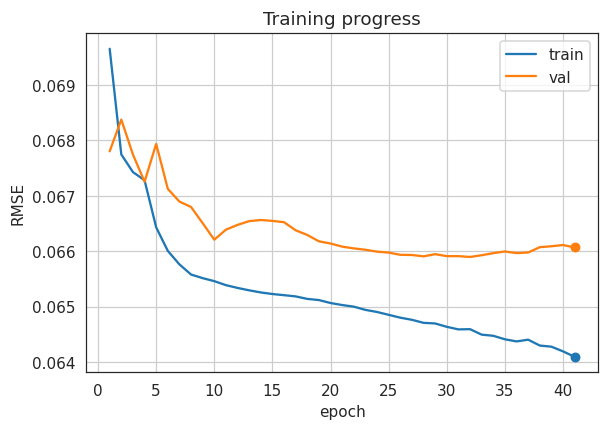

Epoch 1 ▶ Train:   0%|          | 0/224 [00:00<?, ?it/s]

eval:   0%|          | 0/48 [00:00<?, ?it/s]

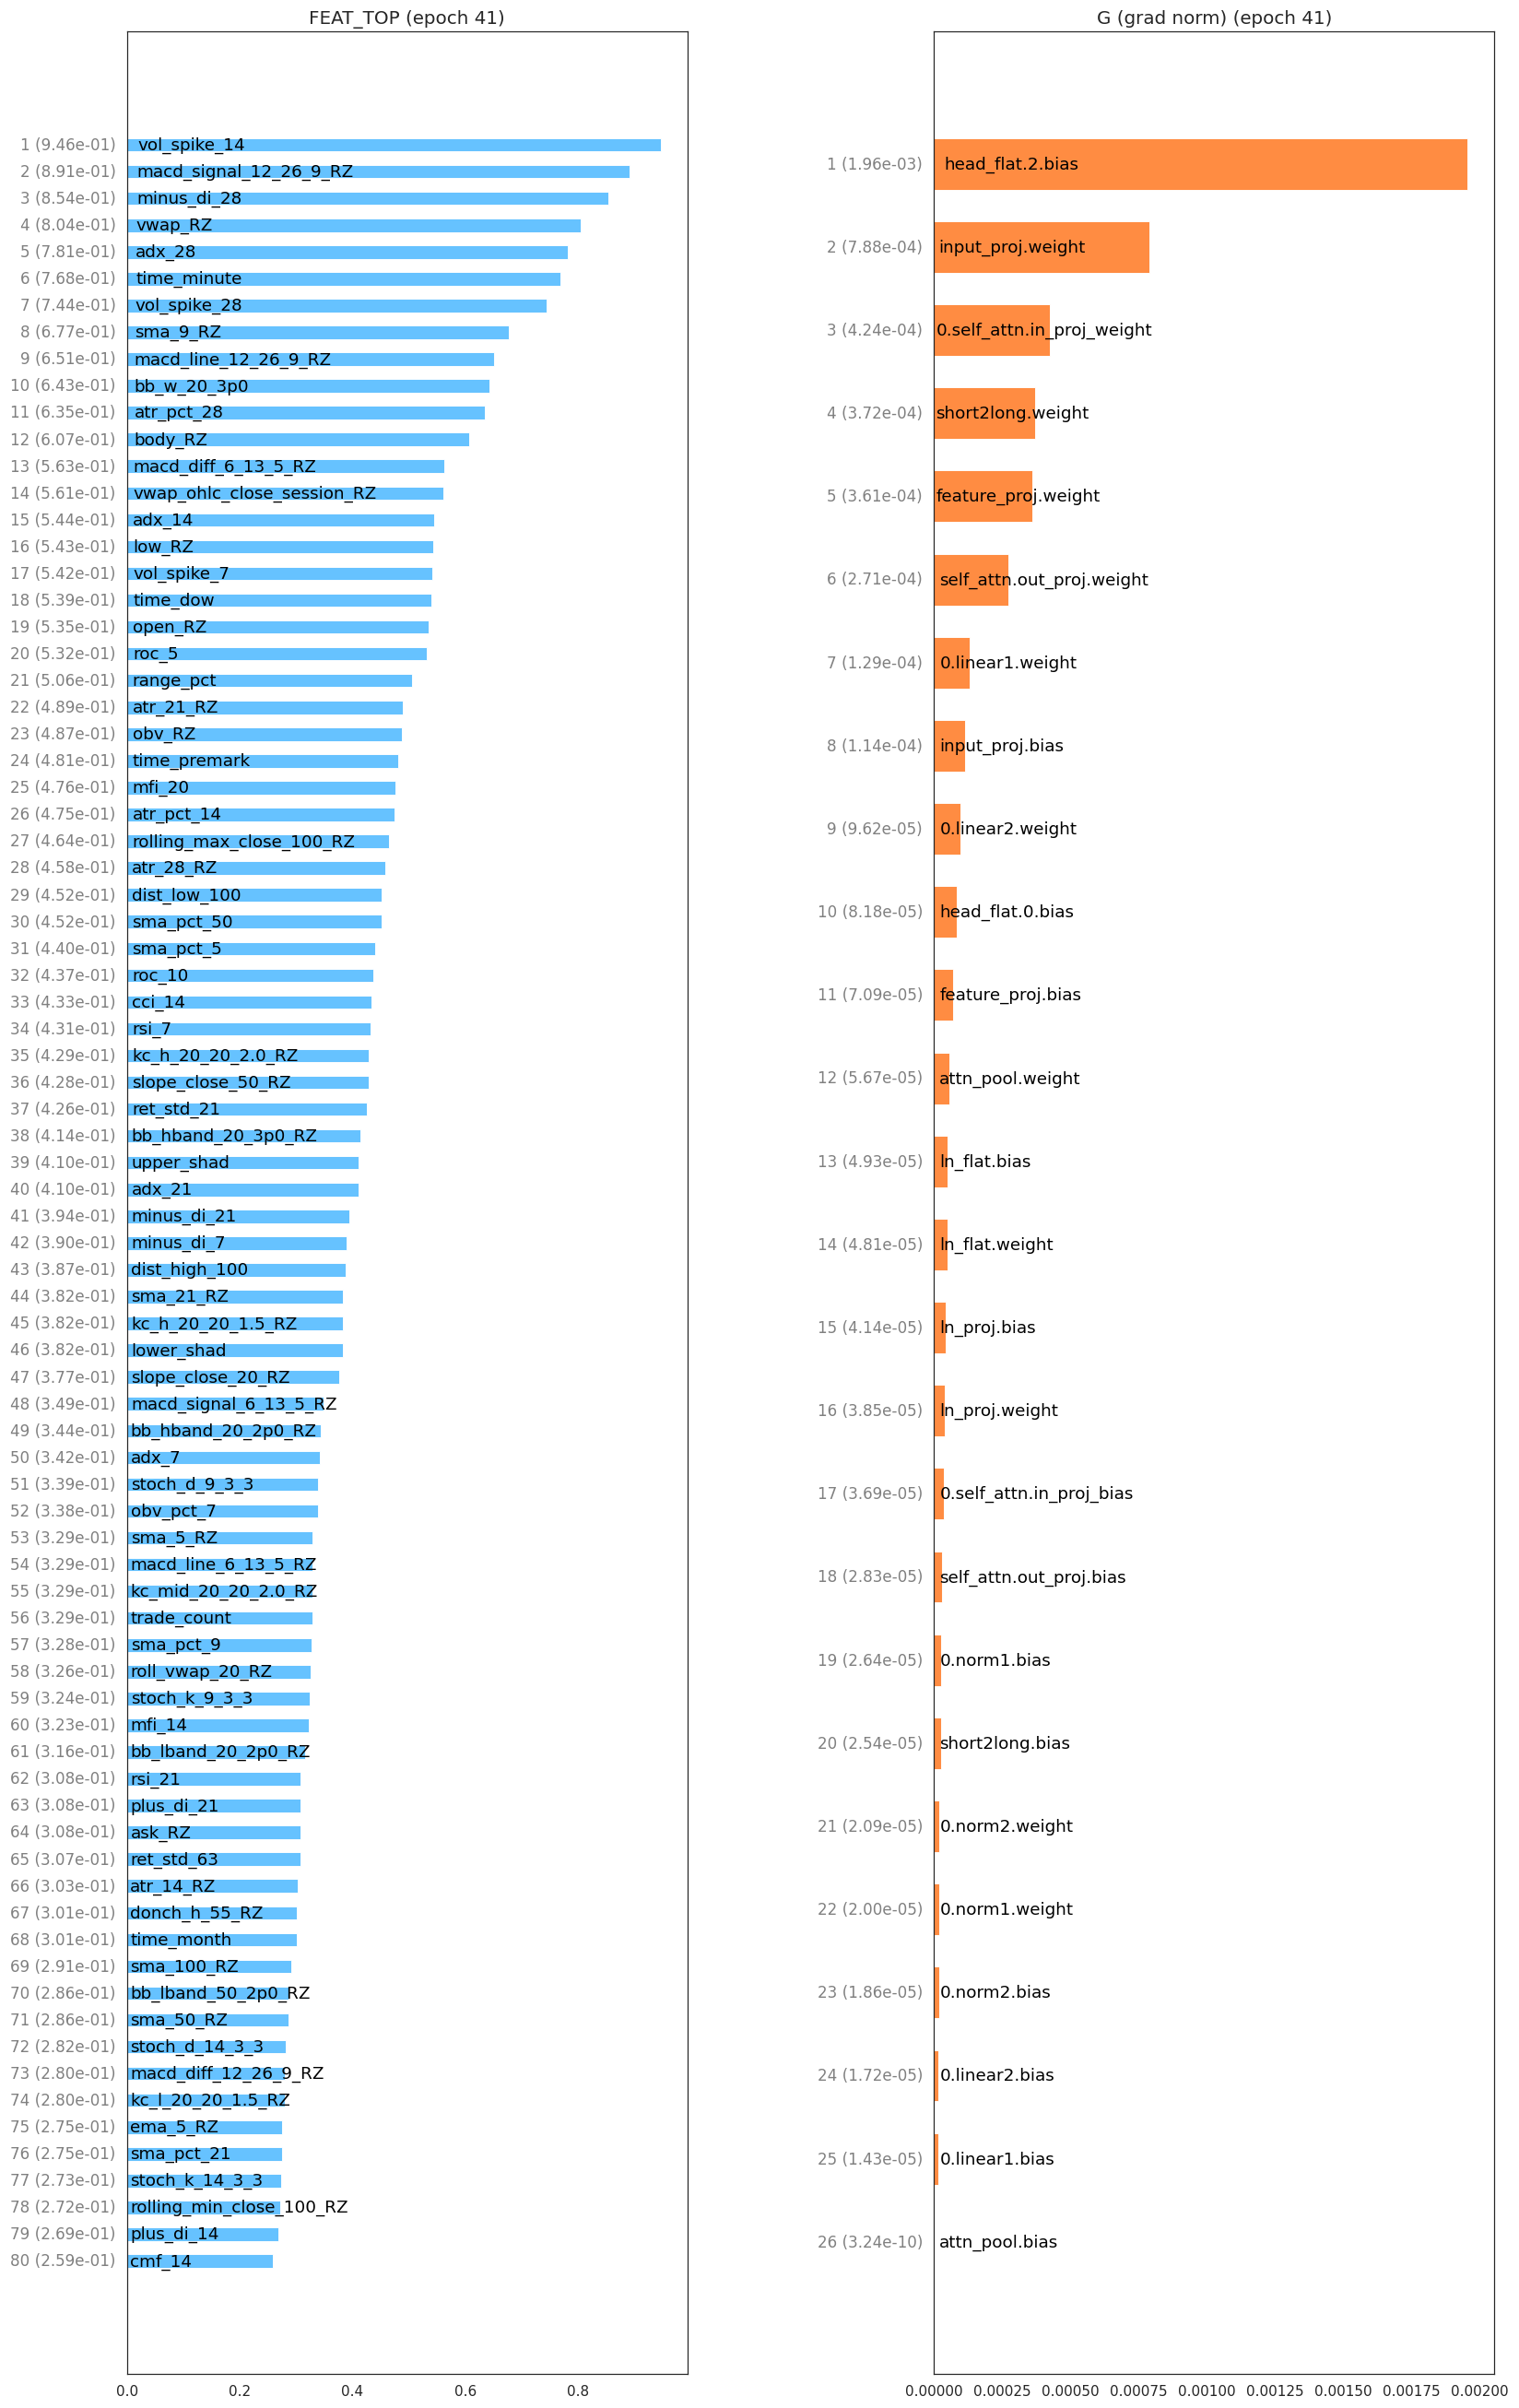

🔖 Saved folder-best checkpoint (_chp): AAPL_0.06780_chp.pth
Epoch 01 | TRAIN→ RMSE=0.06965, R²=-0.070, 56.9s (3.9 batch/s) | VALID→ RMSE=0.06780, R²=0.014, 8.6s (5.6 batch/s) | loss=4.84776e-03 | improved=True


Epoch 2 ▶ Train:   0%|          | 0/224 [00:00<?, ?it/s]

eval:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 02 | TRAIN→ RMSE=0.06775, R²=-0.012, 55.4s (4.0 batch/s) | VALID→ RMSE=0.06837, R²=-0.003, 10.3s (4.7 batch/s) | loss=4.58476e-03 | improved=False


Epoch 3 ▶ Train:   0%|          | 0/224 [00:00<?, ?it/s]

...

eval:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 40 | TRAIN→ RMSE=0.06419, R²=0.091, 55.9s (4.0 batch/s) | VALID→ RMSE=0.06611, R²=0.062, 21.8s (2.2 batch/s) | loss=4.11544e-03 | improved=False


Epoch 41 ▶ Train:   0%|          | 0/224 [00:00<?, ?it/s]

eval:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 41 | TRAIN→ RMSE=0.06409, R²=0.094, 56.6s (4.0 batch/s) | VALID→ RMSE=0.06607, R²=0.063, 21.2s (2.3 batch/s) | loss=4.10295e-03 | improved=False
Early stopping triggered after 41 epochs.
✅ Final-best model saved: AAPL_0.06590_fin.pth


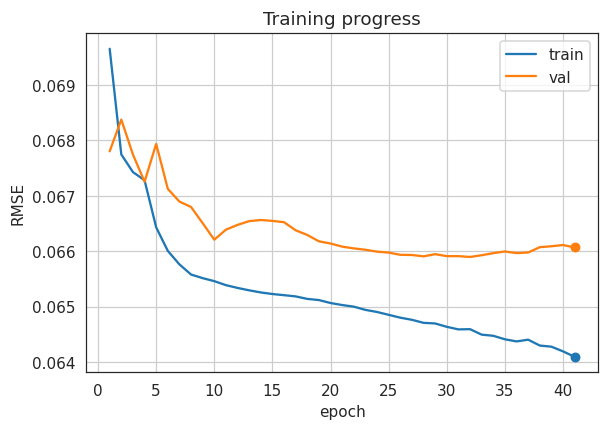

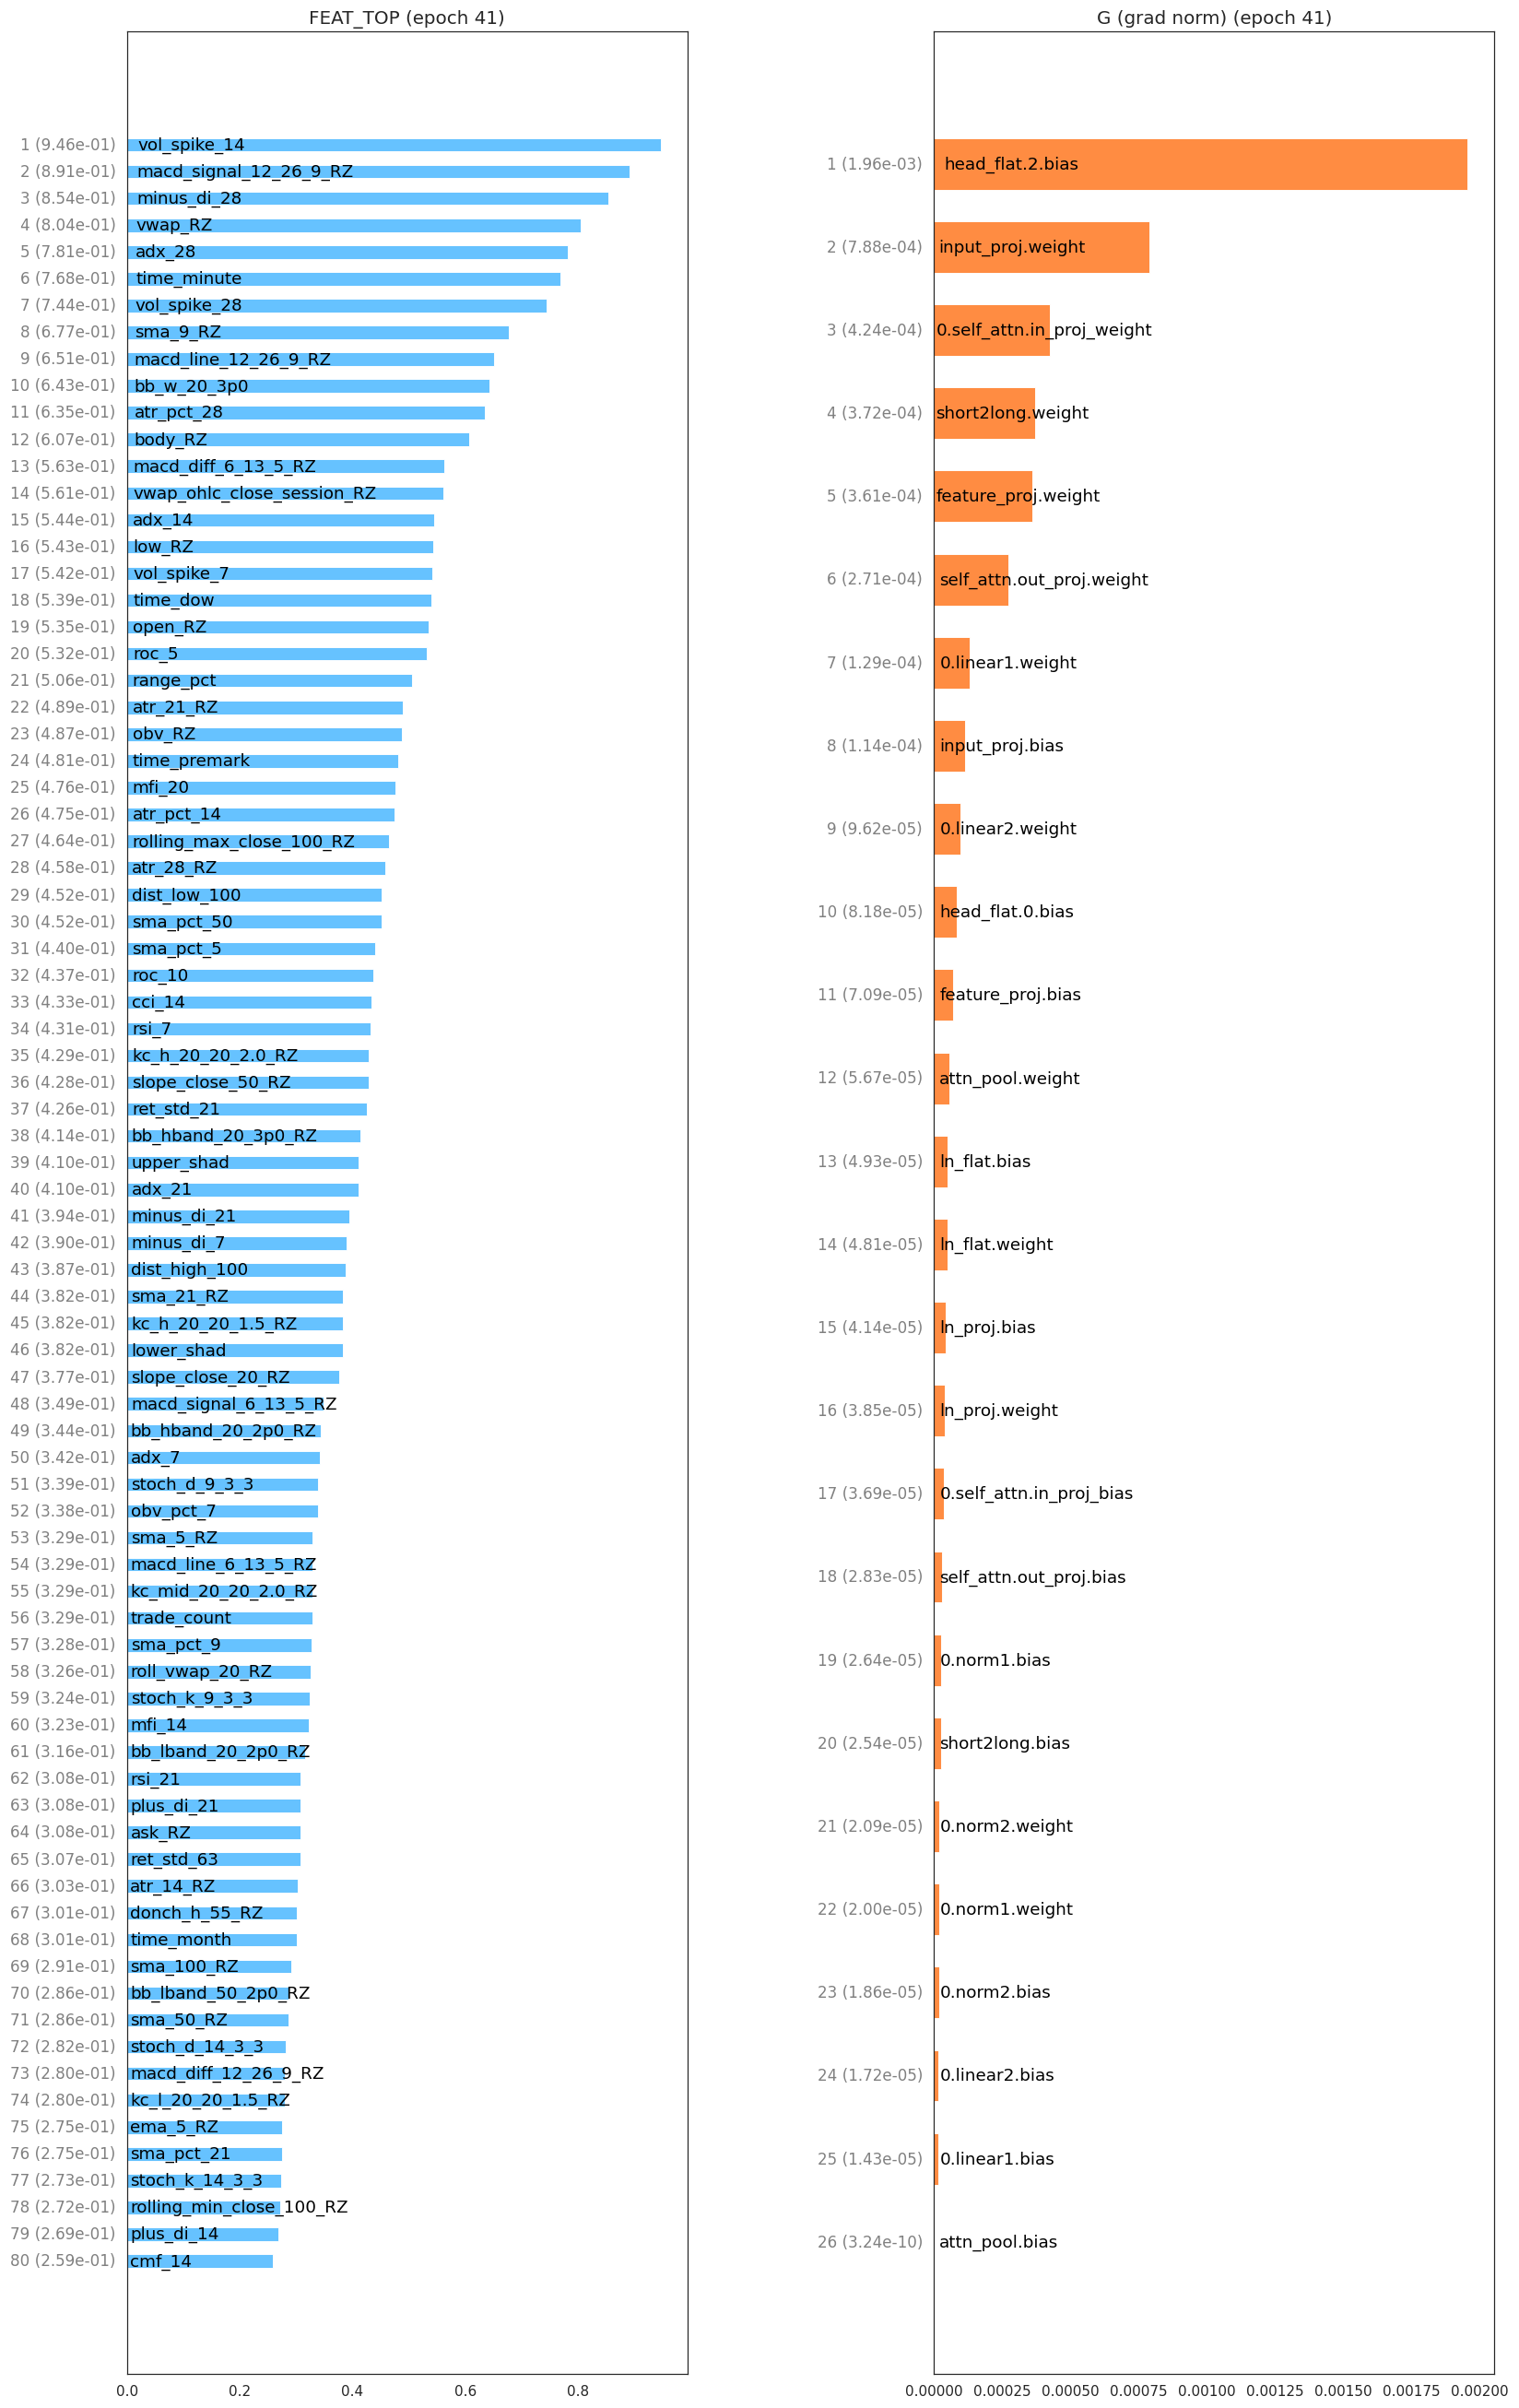

In [8]:
# importlib.reload(models_core)

#################### MODEL TRAINING #####################

model = models_custom.ModelClass(
    n_feats             = len(kept_features),
    short_units         = params.hparams["SHORT_UNITS"],
    long_units          = params.hparams["LONG_UNITS"],
    transformer_d_model = params.hparams["TRANSFORMER_D_MODEL"],
    transformer_layers  = params.hparams["TRANSFORMER_LAYERS"],
    transformer_heads   = params.hparams["TRANSFORMER_HEADS"],    
    transformer_ff_mult = params.hparams["TRANSFORMER_FF_MULT"],   
    dropout_short       = params.hparams["DROPOUT_SHORT"],
    dropout_long        = params.hparams["DROPOUT_LONG"],
    dropout_trans       = params.hparams["DROPOUT_TRANS"],
    pred_hidden         = params.hparams["PRED_HIDDEN"],
    look_back           = params.hparams["LOOK_BACK"],

    # Gating flags
    use_conv            = params.hparams["USE_CONV"],
    use_tcn             = params.hparams["USE_TCN"],
    use_short_lstm      = params.hparams["USE_SHORT_LSTM"],
    use_transformer     = params.hparams["USE_TRANSFORMER"],
    use_long_lstm       = params.hparams["USE_LONG_LSTM"],
    use_delta           = params.hparams["USE_DELTA"],
    flatten_mode        = params.hparams["FLATTEN_MODE"]
)

model.feature_names = kept_features # for logging
model.to(params.device)  
    
optimizer = AdamW(
  model.parameters(),
  lr           = params.hparams["ONECYCLE_MAX_LR"],
  weight_decay = params.hparams["WEIGHT_DECAY"],
  fused        = True
)

batches_per_epoch = len(train_loader)
total_steps = batches_per_epoch * params.hparams["MAX_EPOCHS"]

scheduler = OneCycleLR(
  optimizer,
  max_lr           = params.hparams["ONECYCLE_MAX_LR"],
  total_steps      = total_steps,
  pct_start        = params.hparams["ONECYCLE_PCT_START"],
  div_factor       = params.hparams["ONECYCLE_DIV_FACTOR"],
  final_div_factor = params.hparams["ONECYCLE_FINAL_DIV"],
  anneal_strategy  = params.hparams["ONECYCLE_STRATEGY"],
)
optimizer.scheduler = scheduler # necessary to log sched_field

if getattr(scheduler, "total_steps", None) != total_steps:
    raise RuntimeError(f"Scheduler total_steps mismatch: scheduler={getattr(scheduler,'total_steps',None)} expected={total_steps}")

n_days = len(train_loader.dataset)
print(f"Training sees {n_days} unique trading days per epoch.\n")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: total={total_params:,}, trainable={trainable_params:,}\n")
print('Using HyperParameters:\n', params.hparams)
print('\ntorch.cuda.is_available', torch.cuda.is_available())

# -----------------------------------------------------------------------------
# Run the custom stateful training loop
# -----------------------------------------------------------------------------
best_val_rmse  = models_custom.model_training_loop(
    model               = model,
    optimizer           = optimizer,
    scheduler           = scheduler,
    scaler              = GradScaler("cuda"),
    train_loader        = train_loader,
    val_loader          = val_loader,
    all_features        = True
)


In [9]:
# import numpy as np, pandas as pd
# df_check = df_inds_unsc  # the DataFrame you pass to training
# print("shape:", df_check.shape)
# print(df_check.replace([np.inf, -np.inf], np.nan).isna().sum().sort_values(ascending=False).head(40))
